# Exploratory Data Analysis (EDA) & Model Training
The dataset we are using comes from two main logs (Touch and Sensor). Because the *Machine Learning* model requires each observation row (swiping/sensor record) to predict its profile (`Mindful` or `Mindless`), we will perform:
1. **Merge AsOf**: Merge each Touch history with the nearest Sensor record based on *Timestamp*.
2. **EDA**: Analysis of variable distributions.
3. **Preprocessing**: Handling Missing Values, Encoding, Scaling.
4. **Training**: *Random Forest*, *XGBoost*, and *SVM*.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load Master Data
touch_df = pd.read_csv('master/Master_TouchLog_All.csv')
sensor_df = pd.read_csv('master/Master_SensorLog_All.csv')

# Clean and sort by Timestamp for Merge AsOf mechanism
touch_df = touch_df.dropna(subset=['Timestamp']).sort_values('Timestamp')
sensor_df = sensor_df.dropna(subset=['Timestamp']).sort_values('Timestamp')

# Ensure Timestamp is integer type
touch_df['Timestamp'] = touch_df['Timestamp'].astype(np.int64)
sensor_df['Timestamp'] = sensor_df['Timestamp'].astype(np.int64)

# Merge data based on nearest timestamp with a tolerance of 1000 milliseconds (1 second)
# This ensures each screen swipe activity has a device position/acceleration reference
df_merged = pd.merge_asof(
    touch_df, 
    sensor_df[['Timestamp', 'Magnitude', 'Pitch', 'Roll', 'Participant_ID', 'Condition']], 
    on='Timestamp', 
    by=['Participant_ID', 'Condition'],
    direction='nearest',
    tolerance=1000
)

print(f"Total rows after merging: {len(df_merged)}")
df_merged.head()

Total rows after merging: 15884


,Timestamp,Event_Type,ScrollDeltaX,ScrollDeltaY,PackageName,Time_Delta_Sec,Swipe_Distance,Scroll_Velocity,Participant_ID,Condition,Magnitude,Pitch,Roll
0,1777454311634,SCROLL,168,0,com.ss.android.ugc.trill,NaN,168.0,NaN,P-001,Mindful,9.988351,-0.150985,-2.272232
1,1777454313936,CLICK,0,0,com.ss.android.ugc.trill,2.302,0.0,0.0,P-001,Mindful,0.112743,NaN,NaN
2,1777454314805,SCROLL,0,0,com.ss.android.ugc.trill,0.869,0.0,0.0,P-001,Mindful,9.872883,22.215202,-1.147563
3,1777454318885,SCROLL,0,0,com.ss.android.ugc.trill,4.080,0.0,0.0,P-001,Mindful,0.553474,NaN,NaN
4,1777454319319,SCROLL,0,0,com.ss.android.ugc.trill,0.434,0.0,0.0,P-001,Mindful,0.209587,NaN,NaN


---
### EDA (Exploratory Data Analysis)

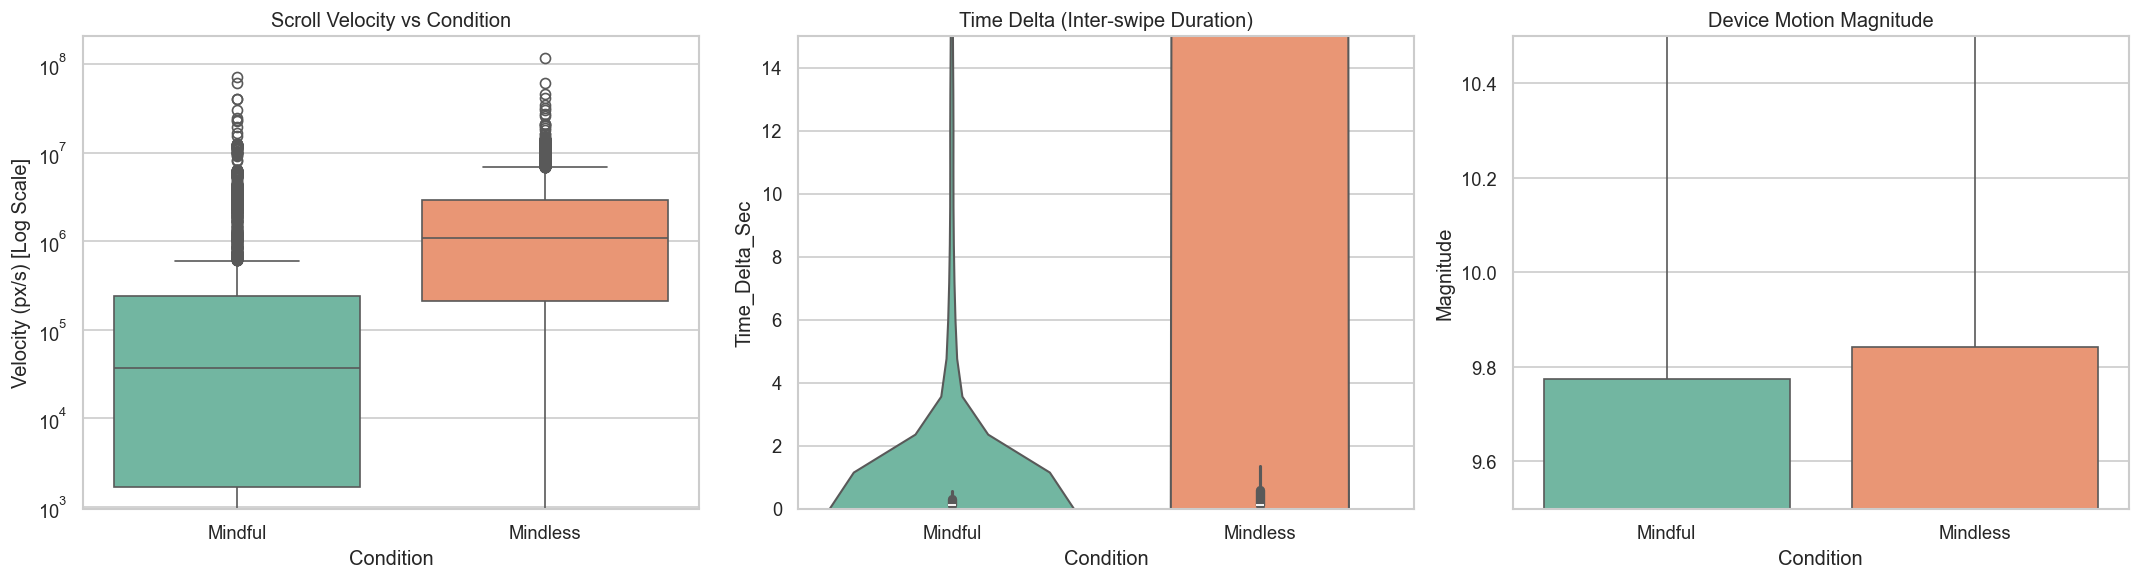

In [22]:
# Set visualization
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scroll Velocity
sns.boxplot(data=df_merged, x='Condition', y='Scroll_Velocity', palette='Set2', ax=axes[0])
axes[0].set_title('Scroll Velocity vs Condition')
axes[0].set_yscale('log') # Because mindless scrolling often has anomalous tails (flicking too fast)
axes[0].set_ylabel('Velocity (px/s) [Log Scale]')

# Plot 2: Inter-swipe Duration
sns.violinplot(data=df_merged, x='Condition', y='Time_Delta_Sec', palette='Set2', ax=axes[1])
axes[1].set_title('Time Delta (Inter-swipe Duration)')
axes[1].set_ylim(0, 15) # Cut to reasonable limits

# Plot 3: Device Physical Magnitude
sns.boxplot(data=df_merged, x='Condition', y='Magnitude', palette='Set2', ax=axes[2])
axes[2].set_title('Device Motion Magnitude')
axes[2].set_ylim(9.5, 10.5) # Focus near gravity 9.8

plt.tight_layout()
plt.show()

---
### Data Preprocessing
Removing Nulls from numerical features, performing Encoding on the Label (`Condition`), and Feature Standardization before feeding into the *Machine Learning Model*.

In [23]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature columns
feature_cols = ['Time_Delta_Sec', 'Swipe_Distance', 'Scroll_Velocity', 'Magnitude', 'Pitch', 'Roll']

# Clean Data
df_model = df_merged.copy()
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model = df_model.dropna(subset=feature_cols)

X = df_model[feature_cols]

# Target Label (Mindful = 0, Mindless = 1)
le = LabelEncoder()
y = le.fit_transform(df_model['Condition'])

# Extract Label Info
print("Original vs Encoded Label Mapping:")
for class_map in zip(le.classes_, le.transform(le.classes_)):
    print(class_map)

# Prevent Data Leakage by grouping Participants
groups = df_model['Participant_ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Save Participant IDs so we know who is in the test set
    test_groups = groups.iloc[test_idx].unique()

print(f"Training data: {X_train.shape[0]}")
print(f"Testing data: {X_test.shape[0]}")
print(f"Participants exclusively used for TESTING: {test_groups}")

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Original vs Encoded Label Mapping:
('Mindful', 0)
('Mindless', 1)
Training data: 6299
Testing data: 1639
Participants exclusively used for TESTING: <ArrowStringArray>
['P-001', 'P-002', 'P-016', 'P-018']
Length: 4, dtype: str


---
### Model Training & Evaluation

In [24]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Initialize Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss'),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42)
}

results = []

print("=== Model Training Process ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    # Default is average='binary', focusing on the positive class (1 = Mindless)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred, digits=6))
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1
    })

# Show Evaluation Summary
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
results_df

=== Model Training Process ===

Training Random Forest...
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0   0.714286  0.843023  0.773333       516
           1   0.921359  0.845058  0.881561      1123

    accuracy                       0.844417      1639
   macro avg   0.817822  0.844041  0.827447      1639
weighted avg   0.856167  0.844417  0.847488      1639


Training XGBoost...
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0   0.668863  0.786822  0.723063       516
           1   0.893411  0.821015  0.855684      1123

    accuracy                       0.810250      1639
   macro avg   0.781137  0.803918  0.789374      1639
weighted avg   0.822717  0.810250  0.813932      1639


Training SVM (RBF)...
Classification Report for SVM (RBF):
              precision    recall  f1-score   support

           0   0.570188  0.763566  0.652858       516
           1   0.87130

,Model,Accuracy,F1-Score
0,Random Forest,0.844417,0.881561
1,XGBoost,0.810250,0.855684
2,SVM (RBF),0.744356,0.797682
